## Boolean networks <a class="anchor" id="bn"></a>

In [ ]:
# --------------
# Notebook setup
# --------------

%matplotlib inline

# Standard library

import gzip
import os
from collections import defaultdict
from itertools import combinations
from pathlib import Path

# Third-party packages

import mpbn
import bonesistools as bt

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from goatools.goea.go_enrichment_ns import GOEnrichmentStudyNS
from goatools.obo_parser import GODag

from IPython.display import display

# Global display and plotting settings

pd.set_option("future.no_silent_downcasting", True)
bt.omics.pl.set_default_params()

plt.rcParams["xtick.labelsize"] = 16
plt.rcParams["ytick.labelsize"] = 16
plt.rcParams["legend.fontsize"] = 16

# Case-study directories

def find_project_root(start=None, markers=(".git", "apl")):
    """Locate the case-study root directory from any notebook location."""

    start = Path.cwd() if start is None else Path(start).resolve()

    for path in (start, *start.parents):
        if all((path / marker).exists() for marker in markers):
            return path

    raise FileNotFoundError(
        f"Could not find project root from {start} using markers {markers}"
    )

PROJECT_DIR = find_project_root()
APL_DIR = PROJECT_DIR / "apl"

DATA_DIR = APL_DIR / "data"
FIGURE_DIR = APL_DIR / "figures"
GO_DIR = PROJECT_DIR / "public" / "go"
GENE2GO_FILE = (
    GO_DIR / "gene2go.gz"
    if (GO_DIR / "gene2go.gz").exists()
    else GO_DIR / "gene2go"
)

FIGURE_DIR.mkdir(exist_ok=True)

# Biological settings

conditions = ["ctrl", "treated"]
labels_order = ["Prom1", "Prom2", "Rep", "Cycl", "Neu", "Alt"]
go_category_to_namespace = {"Process": "BP", "Function": "MF", "Component": "CC"}

GENEINFO_VERSION = "bundled"
PRIOR_KNOWLEDGE = "dorothea"
DOROTHEA_API = "legacy"
DOROTHEA_LEVELS = ["A"]
DOROTHEA_COMPATIBILITY = True
OMNIPATH_VERSION = "2025-08-13"
HCOP_VERSION = "bundled"

genesyn = bt.resources.ncbi.genesyn(
    organism="mouse",
    version=GENEINFO_VERSION,
)

# Notebook helper functions

def display_counts(counts, index_name="item", count_name="n"):
    """Display a compact count summary."""

    summary = pd.DataFrame(
        [(name, count) for name, count in counts.items()],
        columns=[index_name, count_name],
    )
    display(summary.style.hide(axis="index"))

def split_macrostate(name):
    condition, macrostate = name.split("_", 1)
    return condition, macrostate

def fixed_shared_components(hc1, hc2):
    """Return features fixed in both hypercubes."""

    return [
        component
        for component in hc1.components & hc2.components
        if hc1[component].is_fixed and hc2[component].is_fixed
    ]

def hypercube_distance(hc1, hc2):
    """Count mismatching binarised features between two hypercubes."""

    return sum(
        hc1[component] != hc2[component]
        for component in fixed_shared_components(hc1, hc2)
    )

def hypercube_maximum(hc1, hc2):
    """Count jointly defined features between two hypercubes."""

    return len(fixed_shared_components(hc1, hc2))

def as_mpbn_state(hypercube):
    """Convert a Hypercube to an mpbn-compatible partial state."""

    return {
        component: value.value
        for component, value in dict(hypercube).items()
        if value.is_fixed
    }

def to_gene_ids(genes, genesyn):
    """Convert gene symbols to NCBI Gene IDs."""

    converted = genesyn(
        sorted(set(genes)),
        input_identifier_type="name",
        output_identifier_type="gene_id",
    )

    gene_ids = set()
    for gene_id in converted:
        if isinstance(gene_id, (int, np.integer)):
            gene_ids.add(int(gene_id))
        elif isinstance(gene_id, str) and gene_id.isnumeric():
            gene_ids.add(int(gene_id))

    return gene_ids

def read_gene2go_associations(path, gene_ids, tax_id=10090):
    """Read gene-to-GO associations for selected NCBI Gene IDs."""

    gene_ids = set(gene_ids)
    associations = {
        namespace: defaultdict(set)
        for namespace in go_category_to_namespace.values()
    }
    opener = gzip.open if path.suffix == ".gz" else open

    with opener(path, "rt") as reader:
        next(reader)
        for line in reader:
            fields = line.rstrip("\n").split("\t")
            if len(fields) < 8 or fields[0] != str(tax_id):
                continue

            gene_id = int(fields[1])
            if gene_id not in gene_ids:
                continue

            namespace = go_category_to_namespace.get(fields[7])
            if namespace is not None:
                associations[namespace][gene_id].add(fields[2])

    return {namespace: dict(values) for namespace, values in associations.items()}

def goea_results_dataframe(results):
    """Convert GOATOOLS enrichment results to a compact dataframe."""

    return pd.DataFrame(
        [
            {
                "GO": result.GO,
                "NS": result.NS,
                "name": result.name,
                "enrichment": result.enrichment,
                "p_fdr_bh": result.p_fdr_bh,
                "study_count": result.study_count,
                "study_n": result.study_n,
                "pop_count": result.pop_count,
                "pop_n": result.pop_n,
            }
            for result in results
        ]
    )

def pairwise_hypercube_matrix(hypercubes, metric):
    """Build a symmetric pairwise matrix from a hypercube metric."""

    names = list(hypercubes)
    matrix = pd.DataFrame(np.nan, index=names, columns=names, dtype=float)

    for name in names:
        matrix.at[name, name] = metric(hypercubes[name], hypercubes[name])

    for name1, name2 in combinations(names, 2):
        value = metric(hypercubes[name1], hypercubes[name2])
        matrix.at[name1, name2] = value
        matrix.at[name2, name1] = value

    return matrix

def order_macrostate_matrix(matrix):
    """Order a macrostate matrix by condition and biological label."""

    matrix = matrix.copy()
    matrix.index = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.index],
    )
    matrix.columns = pd.MultiIndex.from_tuples(
        [split_macrostate(name) for name in matrix.columns],
    )

    ordered_index = [
        (condition, label)
        for condition in conditions
        for label in labels_order
        if (condition, label) in matrix.index
    ]

    return matrix.loc[ordered_index, ordered_index].rename_axis(
        index=[None, None],
        columns=[None, None],
    )

def upper_triangle(matrix):
    """Hide the lower triangle of a square matrix."""

    mask = np.tril(np.ones(matrix.shape, dtype=bool), k=-1)
    return matrix.mask(mask)

def plot_counts(
    counts,
    title=None,
):
    if not counts:
        raise ValueError("counts must not be empty")

    keys = sorted(counts)
    values = [counts[key] for key in keys]

    fig, ax = plt.subplots()

    ax.bar(
        keys,
        values,
        width=1,
        facecolor=bt.omics.pl.get_color("pink"),
        edgecolor=bt.omics.pl.get_color("red"),
        linewidth=1.5,
    )

    ax.set_xlim(keys[0] - 0.6, keys[-1] + 0.6)
    ax.set_ylim(0, max(values) + 1)

    if title is not None:
        ax.set_title(title)

    return fig, ax

## Data overview <a class="anchor" id="data"></a>

### Load Boolean Networks

Two objects generated by scBOLT are loaded:

* partially binarised macrostates;
* subset-minimal Boolean networks;

In [9]:
bn_dirs = sorted(
    [
        path
        for path in (DATA_DIR / "bn" / "submin").iterdir()
        if path.is_dir()
        and (path / "model.bnet").exists()
        and (path / "state.csv").exists()
    ],
    key=lambda path: int(path.name),
)

bns = []
configs = []
mpbn_configs = []

for path in bn_dirs:
    config = bt.logic.io.read_hypercubes(path / "state.csv", orientation="columns")

    bns.append(bt.logic.io.read_bnet(path / "model.bnet"))
    configs.append(config)
    mpbn_configs.append(
        {
            name: as_mpbn_state(hypercube)
            for name, hypercube in config.items()
        }
    )

bns = bt.logic.bn.BooleanNetworkEnsemble(bns=bns)
mpbns = bns.convert("mpbn")
components = bns.components

mstate_hypercubes = bt.logic.io.read_hypercubes(
    DATA_DIR / "mstates_bin.csv",
    orientation="rows",
)
features = set().union(*(hc.components for hc in mstate_hypercubes.values()))

mstate_hypercubes = {
    name: hc.drop(set(hc.components) - set(components))
    for name, hc in mstate_hypercubes.items()
}

#mstates_df = pd.read_csv(
#    DATA_DIR / "mstates_bin.csv",
#    index_col=0
#).fillna("*").replace("-", "_")
#features = set(mstates_df.columns)
#mstates_df = mstates_df[[component for component in components if component in mstates_df.columns]]

display_counts(
    {
        "macrostates": len(mstate_hypercubes),
        "boolean networks": len(bns),
        "components": len(components),
    },
    index_name="",
)

components_in_bin_and_bn = components.intersection(features)
components_in_bn_notin_bin = components.difference(features)

component_summary = display_counts(
    {
        "in binarisation": len(features),
        "in BNs": len(components),
        "intersection": len(components & features),
        "difference": len(components - features),
    },
    index_name="",
    count_name="n_components",
)


,n
macrostates,9
boolean networks,1000
components,193


,n_components
in binarisation,3228
in BNs,193
intersection,167
difference,26


### Structural property overview

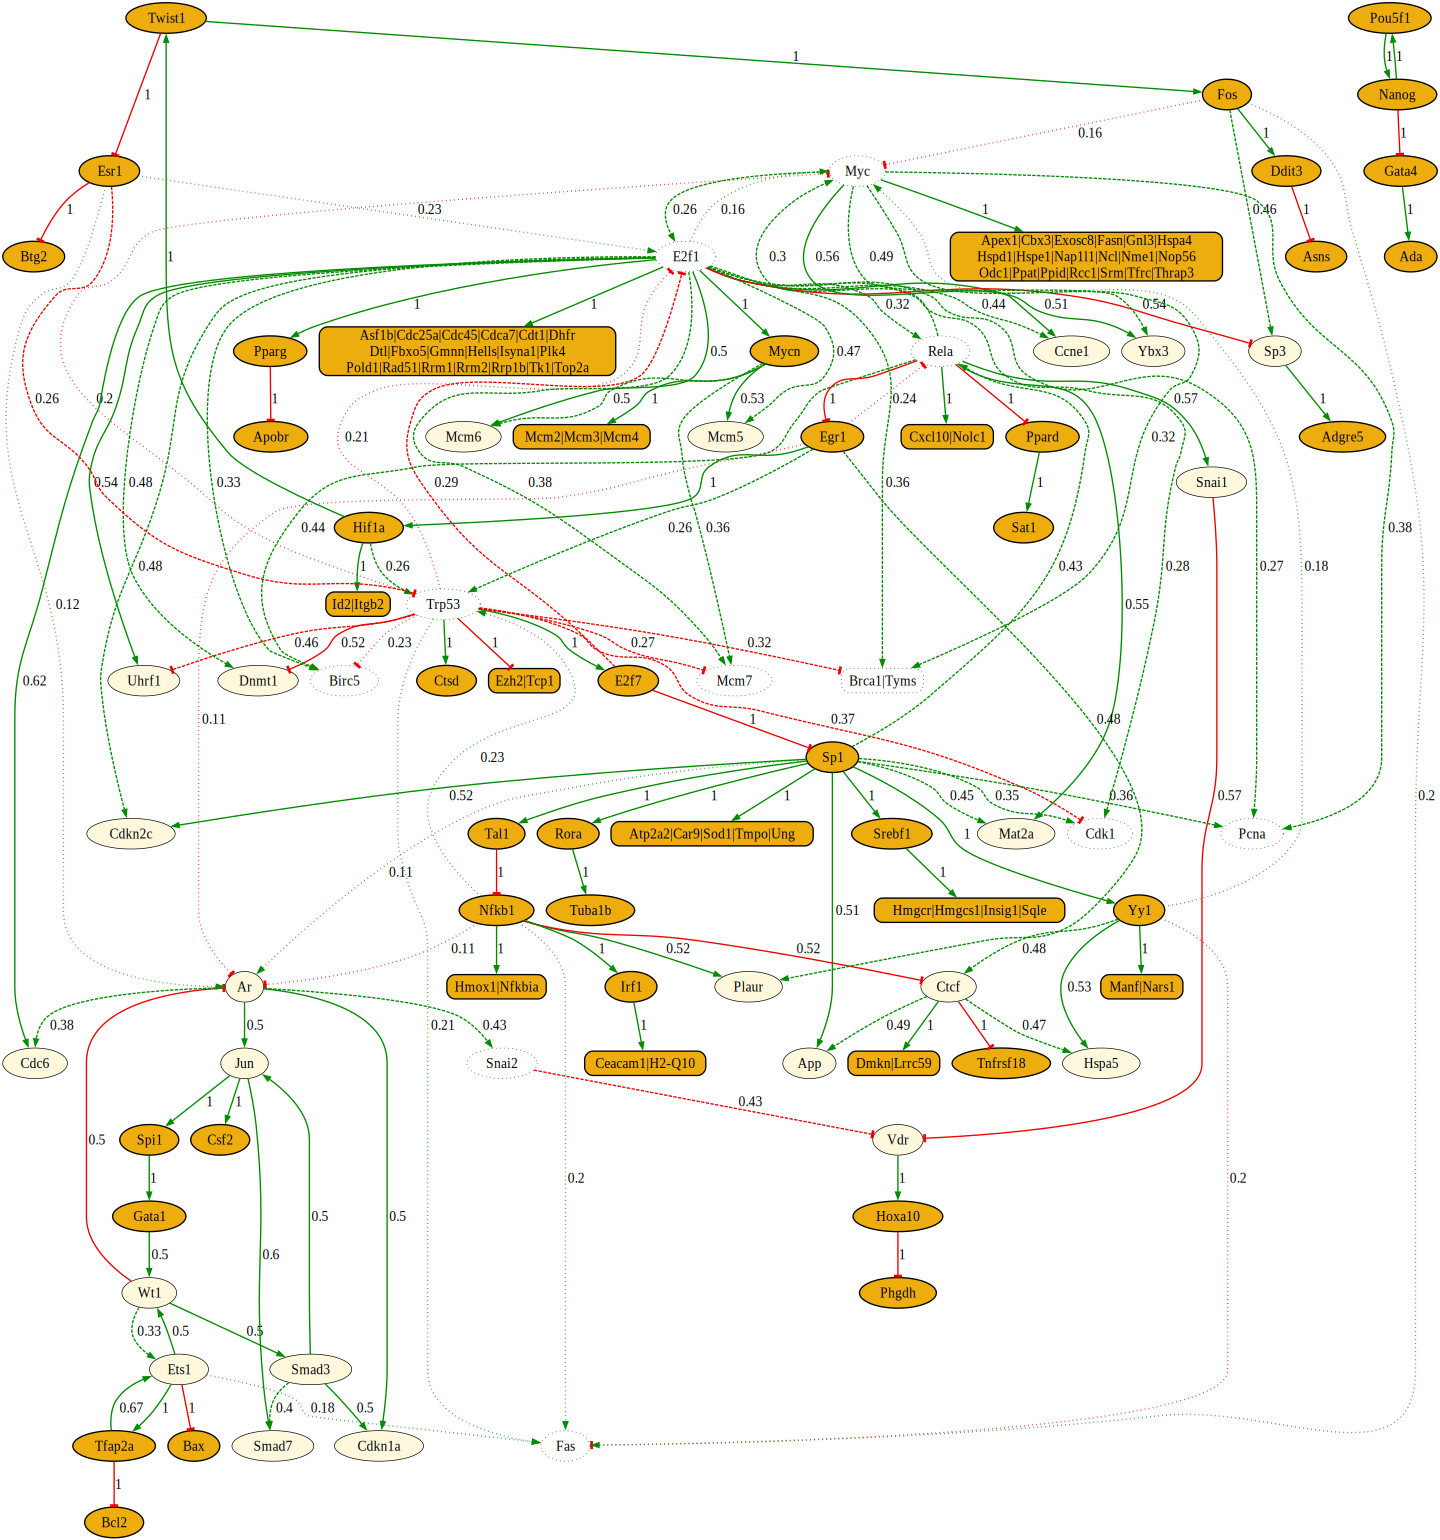

In [10]:
ig = bt.logic.ig.AggregatedInfluenceGraph.from_boolean_networks(bns)

ig.show(
    collapse="family",
    drop_isolates=True,
    edge_label="frequency",
    graph_attr={
        "ratio": "compress",
        "size": "20,30!",
        "overlap": "prism",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "ranksep": "0.6",
        "pack": "true",
        "rankdir": "TB",
        "splines": "curve",
    },
    node_attr={
        "fontsize": "20",
    },
    node_style="stability",
    edge_attr={
        "fontsize": "20",
    },
    edge_style="frequency",
    width="100%",
)

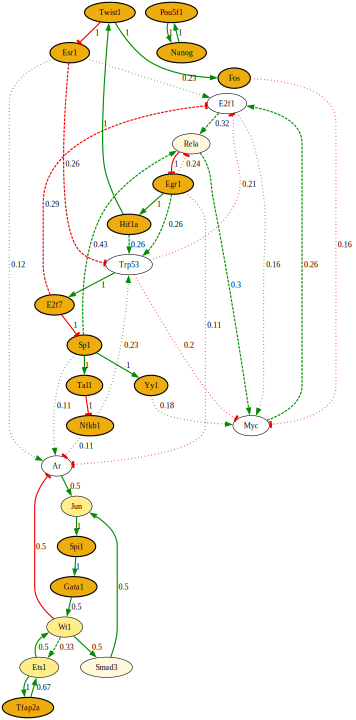

In [11]:
ig.show(
    collapse="both",
    drop_isolates=True,
    edge_label="frequency",
    node_style="count",
    preserve_feedback=True,
    include_selfloops=False,
    min_frequency=0,
    program="dot",
    graph_attr={
        "ratio": "compress",
        "size": "10,10!",
        "rankdir": "TB",
        "splines": "curve",
        "ranksep": "0.25",
        "pack": "true",
        "sep": "+0",
        "esep": "+0",
        "K": "0.35",
        "overlap": "prism",
    },
)

### 2. Gene selection enrichment analysis <a class="anchor" id="enrichment"></a>

The subset-minimal Boolean networks contain 193 unique components. These genes are tested for Gene Ontology enrichment using the DoRothEA legacy prior network used by scBOLT as background. The panel below reports the top 20 enriched biological process (BP) terms ranked by FDR.

In [ ]:
selected_genes = sorted(components)
prior_knowledge = bt.resources.omnipath.dorothea(
    organism="mouse",
    levels=DOROTHEA_LEVELS,
    genesyn=genesyn,
    version=OMNIPATH_VERSION,
    hcop_version=HCOP_VERSION,
    compatibility=DOROTHEA_COMPATIBILITY,
    flavor=DOROTHEA_API,
)
go_background = sorted(prior_knowledge.nodes)

selected_gene_ids = to_gene_ids(selected_genes, genesyn)
background_gene_ids = to_gene_ids(go_background, genesyn)
missing_gene_ids = selected_gene_ids - background_gene_ids

if missing_gene_ids:
    raise ValueError(
        f"{len(missing_gene_ids)} BoNesis component Gene IDs are absent from "
        "the DoRothEA background."
    )

display_counts(
    {
        "DoRothEA edges": prior_knowledge.number_of_edges(),
        "DoRothEA genes": len(go_background),
        "BoNesis components": len(selected_genes),
        "GO-mapped BoNesis components": len(selected_gene_ids),
        "GO-mapped DoRothEA genes": len(background_gene_ids),
    },
    index_name="set",
    count_name="n_genes",
)

with open(os.devnull, "w") as log:
    go_dag = GODag(str(GO_DIR / "go_basic.obo"), prt=log)

associations = read_gene2go_associations(
    GENE2GO_FILE,
    gene_ids=background_gene_ids,
)

with open(os.devnull, "w") as log:
    goea = GOEnrichmentStudyNS(
        pop=background_gene_ids,
        ns2assoc=associations,
        godag=go_dag,
        propagate_counts=False,
        alpha=0.05,
        methods=["fdr_bh"],
        log=log,
    )

with open(os.devnull, "w") as log:
    goea_results = goea_results_dataframe(
        goea.run_study(study_ids=selected_gene_ids, log=log)
    )

bp_enrichment = (
    goea_results
    .query("NS == 'BP' and enrichment == 'e'")
    .sort_values("p_fdr_bh", kind="mergesort")
    .reset_index(drop=True)
)
top_bp_terms = bp_enrichment.head(20).copy()

if top_bp_terms.empty:
    raise ValueError("No enriched GO BP term found for the BoNesis components.")

top_bp_terms["minus_log10_fdr"] = -np.log10(
    top_bp_terms["p_fdr_bh"].clip(lower=np.finfo(float).tiny)
)

display(
    top_bp_terms[
        ["GO", "name", "p_fdr_bh", "study_count", "pop_count", "minus_log10_fdr"]
    ]
    .style.hide(axis="index")
    .format({"p_fdr_bh": "{:.2e}", "minus_log10_fdr": "{:.2f}"})
)

fig, ax = plt.subplots(figsize=(8, 6))
plot_df = top_bp_terms.iloc[::-1]

ax.barh(
    plot_df["name"],
    plot_df["minus_log10_fdr"],
    color=bt.omics.pl.get_color("pink"),
    edgecolor=bt.omics.pl.get_color("red"),
    linewidth=1.2,
)
ax.set_xlabel(r"$-\log_{10}(\mathrm{FDR})$", fontsize=12)
ax.set_ylabel(None)
ax.set_title(
    f"Top enriched GO BP terms (n={len(selected_genes)} genes)",
    fontsize=12,
)
ax.tick_params(axis="both", labelsize=11)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "bn_goea_bp_top20.pdf", bbox_inches="tight")
plt.show()
plt.close()

### 3. Pairwise macrostate distances <a class="anchor" id="distances"></a>

Pairwise distance matrix between macrostates based on the selected Boolean-network components. Each distance is the number of components that are defined in both macrostates and assigned different Boolean values. The corresponding maximum observable distance is the number of components defined in both macrostates, independently of whether their values match or differ. Pairwise similarity can therefore be computed as the maximum observable distance minus the observed distance.

In [5]:
distance = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_distance),
)
maximum = order_macrostate_matrix(
    pairwise_hypercube_matrix(mstate_hypercubes, hypercube_maximum),
)

distance_upper = upper_triangle(distance)
maximum_upper = upper_triangle(maximum)

display(
    distance_upper.style
    .set_caption("Pairwise macrostate distances")
    .format("{:.0f}", na_rep="")
)
display(
    maximum_upper.style
    .set_caption("Jointly binarised genes per macrostate pair")
    .format("{:.0f}", na_rep="")
)

### 4. Reachable attractors <a class="anchor" id="attractors"></a>

In [6]:
# help(bt.logic.io.read_hypercubes)

# mpbns = bns.convert("mpbn")
# 
# init = ["ctrl_Prom1", "treated_Prom1"]
# 
# configs[0]
# bns[0]
# 
# for name in ["ctrl_Prom1"]:
#     attractor_number = pd.Series([len(list(bn.attractors(reachable_from=config[name]))) for bn, config in zip(mpbns, mpbn_configs)]).value_counts().to_dict()


In [7]:
#n_trapspaces = pd.Series(
#    [len(list(mpbn.minimal_trapspaces())) for mpbn in mpbns]
#).value_counts().to_dict()
#
#plot_counts(
#    n_trapspaces,
#    title="minimal trap spaces"
#)
#
#plt.show()
#plt.close()

#k, v = [], []
#for n in sorted(attractor_number.keys()):
#    k.append(n)
#    v.append(attractor_number[n])
#fig, ax = plt.subplots(nrows=1, ncols=1)
#plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
#plt.xlim([k[0]-0.6, k[-1]+0.6])
#plt.ylim(0, max(v)+1)
#plt.title("minimal trap spaces")
#plt.show()
#plt.close()

### 3. Subset minimal BNs <a class="anchor" id="minimal"></a>

In [ ]:
import math

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 60

bns = []
cfgs = []

macrostates = pd.read_csv("data/interest/bin/bin_macrostates.csv", index_col=0).transpose()
for c in set(components) - set(macrostates.index):
    macrostates.loc[c] = pd.Series()
macrostates = macrostates.loc[components,:].replace(math.nan, "*").to_dict()
for k, v in macrostates.items():
    macrostates[k] = bt.logic.Hypercube(v)

configuration_space = dict()
for condition, macrostate in macrostates.items():
    to_remove = []
    for k, v in macrostate.items():
        if isinstance(v, str):
            to_remove.append(k)

    configuration_space[condition] = {
        "n_free_components": len(to_remove),
        "n_configurations": 2 ** len(to_remove),
    }
    for k in to_remove:
        del macrostate[k]

configuration_space = pd.DataFrame.from_dict(configuration_space, orient="index")
configuration_space.index.name = "macrostate"
display(configuration_space)

for i in range(100):
    bns.append(mpbn.MPBooleanNetwork.load(f"data/interest/bn/sub/{i}/sub.bnet"))
    cfg = pd.read_csv(f"data/interest/bn/sub/{i}/metastates.csv", index_col=0).to_dict()
    for k, v in cfg.items():
        cfg[k] = bt.logic.Hypercube(v)
    cfgs.append(cfg)
    del cfg

bns = bt.logic.BooleanNetworkEnsemble(bns=bns)
components = list(bns.get_components())

attractor_number = pd.Series([len(list(bn.attractors())) for bn in bns]).value_counts().to_dict()
k, v = [], []
for n in sorted(attractor_number.keys()):
    k.append(n)
    v.append(attractor_number[n])
fig, ax = plt.subplots(nrows=1, ncols=1)
plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
plt.xlim([k[0]-0.5, k[-1]+0.6])
plt.ylim(0, max(v)+1)
plt.title("From any configurations")
plt.show()
plt.close()

for name in ["ctrl_promyelocytes", "treated_promyelocytes"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=cfg[name]))) for cfg, bn in zip(cfgs, bns)]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From configuration {name}")
    plt.show()
    plt.close()

for name in ["ctrl_prom1", "treated_prom1"]:
    attractor_number = pd.Series([len(list(bn.attractors(reachable_from=macrostates[name]))) for bn in bns]).value_counts().to_dict()
    k, v = [], []
    for n in sorted(attractor_number.keys()):
        k.append(n)
        v.append(attractor_number[n])
    fig, ax = plt.subplots(nrows=1, ncols=1)
    plt.bar(k, v, width=1, facecolor=bt.omics.pl.get_color("pink"), edgecolor=bt.omics.pl.get_color("red"), linewidth=1.5)
    plt.xlim([k[0]-0.5, k[-1]+0.6])
    plt.ylim(0, max(v)+1)
    plt.xticks(k)
    plt.title(f"From macrostate {name}")
    plt.show()
    plt.close()

In [ ]:
macrostate_size_summary = display_counts(
    {name: len(macrostate) for name, macrostate in macrostates.items()},
    index_name="macrostate",
    count_name="n_defined_components",
)
